In [36]:

import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt


In [37]:
#Sample model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # Latent space with 2 dimensions
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # Reconstruct to original 2 dimensions
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [38]:
#Data set
def circlePoints(numSamples,radius=1):
    angles = np.linspace(0,2*np.pi,numSamples)
    xCor= radius * np.cos(angles)
    yCor = radius * np.sin(angles)
    return np.column_stack((xCor,yCor))


In [39]:
#hyper parameters
model = Autoencoder()
numEpochs = 500
lr=0.01
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
circleData = circlePoints(100, 1)
circleData = torch.tensor(circleData, dtype=torch.float32)

In [40]:
# Function to train the model
def trainModel(model, criterion, optimizer, hooks_enabled=False):
    if hooks_enabled:
        # Register hooks if enabled
        invokeCount = 0

        def linearhook(module, input, output):
            nonlocal invokeCount
            """
            - You can play around here with the layer data, manipulate it or build logic to visualize the data
            - For the sake of simplicity and the argument i have just shown how the hooks works
            
            """
            print(f"Forward hook: {module.__class__.__name__}")
            print(f"Input shape: {input[0].shape}")
            print(f"Output shape: {output.shape}")
            print(f"Output mean: {output.mean().item()}\n")
            invokeCount += 1

        # Register hooks to each Linear layer
        for module in model.modules():
            if isinstance(module, nn.Linear):
                module.register_forward_hook(linearhook)

    startTime = time.time()
    for epoch in range(numEpochs):
        optimizer.zero_grad()
        outputs = model(circleData)
        loss = criterion(outputs, circleData)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch + 1}/{numEpochs}], Loss: {loss.item():.4f}')

    endTime = time.time()
    totalTime = endTime - startTime
    print(f"Total training time: {totalTime:.2f} seconds")
    if hooks_enabled:
        print(f"Hooks were invoked {invokeCount} times")

In [41]:
print("Training model without hooks:")
modelNoHook = Autoencoder()
optimizer = optim.Adam(modelNoHook.parameters(), lr=lr)
criterion = nn.MSELoss()
trainModel(modelNoHook, criterion, optimizer, hooks_enabled=False)

Training model without hooks:
Epoch [100/500], Loss: 0.0240
Epoch [200/500], Loss: 0.0008
Epoch [300/500], Loss: 0.0004
Epoch [400/500], Loss: 0.0003
Epoch [500/500], Loss: 0.0003
Total training time: 0.52 seconds


In [42]:
print("\nTraining model with hooks:")
modelHook = Autoencoder()
optimizer = optim.Adam(modelHook.parameters(), lr=lr)
trainModel(modelHook, criterion, optimizer, hooks_enabled=True)



Training model with hooks:
Forward hook: Linear
Input shape: torch.Size([100, 2])
Output shape: torch.Size([100, 64])
Output mean: 0.06412328779697418

Forward hook: Linear
Input shape: torch.Size([100, 64])
Output shape: torch.Size([100, 32])
Output mean: 0.014404264278709888

Forward hook: Linear
Input shape: torch.Size([100, 32])
Output shape: torch.Size([100, 1])
Output mean: 0.002759371418505907

Forward hook: Linear
Input shape: torch.Size([100, 1])
Output shape: torch.Size([100, 32])
Output mean: 0.05499444529414177

Forward hook: Linear
Input shape: torch.Size([100, 32])
Output shape: torch.Size([100, 64])
Output mean: -0.05277089774608612

Forward hook: Linear
Input shape: torch.Size([100, 64])
Output shape: torch.Size([100, 2])
Output mean: 0.09422943741083145

Forward hook: Linear
Input shape: torch.Size([100, 2])
Output shape: torch.Size([100, 64])
Output mean: 0.06538495421409607

Forward hook: Linear
Input shape: torch.Size([100, 64])
Output shape: torch.Size([100, 32])


In [43]:
def visualizeResults(model, title):
    model.eval()
    with torch.no_grad():
        reconstructeData = model(circleData).cpu().numpy()
    circleDataCpu = circleData.cpu().numpy()

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title('Original Circle Data')
    plt.scatter(circleDataCpu[:, 0], circleDataCpu[:, 1])
    plt.subplot(1, 2, 2)
    plt.title(title)
    plt.scatter(reconstructeData[:, 0], reconstructeData[:, 1])
    plt.show()


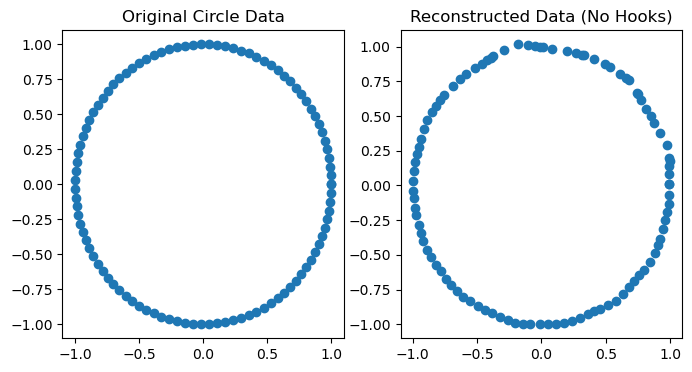

In [44]:
visualizeResults(modelNoHook, 'Reconstructed Data (No Hooks)')

Forward hook: Linear
Input shape: torch.Size([100, 2])
Output shape: torch.Size([100, 64])
Output mean: -0.03225337341427803

Forward hook: Linear
Input shape: torch.Size([100, 64])
Output shape: torch.Size([100, 32])
Output mean: -1.0283879041671753

Forward hook: Linear
Input shape: torch.Size([100, 32])
Output shape: torch.Size([100, 1])
Output mean: 0.06933914124965668

Forward hook: Linear
Input shape: torch.Size([100, 1])
Output shape: torch.Size([100, 32])
Output mean: 0.08969507366418839

Forward hook: Linear
Input shape: torch.Size([100, 32])
Output shape: torch.Size([100, 64])
Output mean: -0.25820571184158325

Forward hook: Linear
Input shape: torch.Size([100, 64])
Output shape: torch.Size([100, 2])
Output mean: 0.005696287378668785



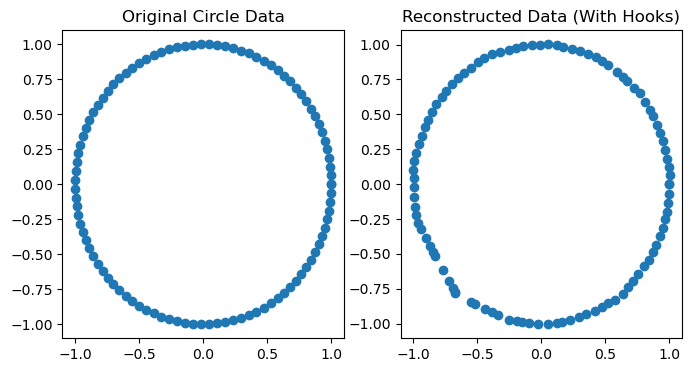

In [45]:
visualizeResults(modelHook, 'Reconstructed Data (With Hooks)')